In [106]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/raw/02_nav_history.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

print(nav.shape)
print(benchmark.shape)

(46000, 3)
(8050, 3)


In [107]:
print(benchmark.columns.tolist())
print(benchmark.head())

['date', 'index_name', 'close_value']
        date index_name  close_value
0 2022-01-03    NIFTY50     17492.79
1 2022-01-04    NIFTY50     17689.64
2 2022-01-05    NIFTY50     17835.05
3 2022-01-06    NIFTY50     17878.51
4 2022-01-07    NIFTY50     17759.15


In [108]:
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [109]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

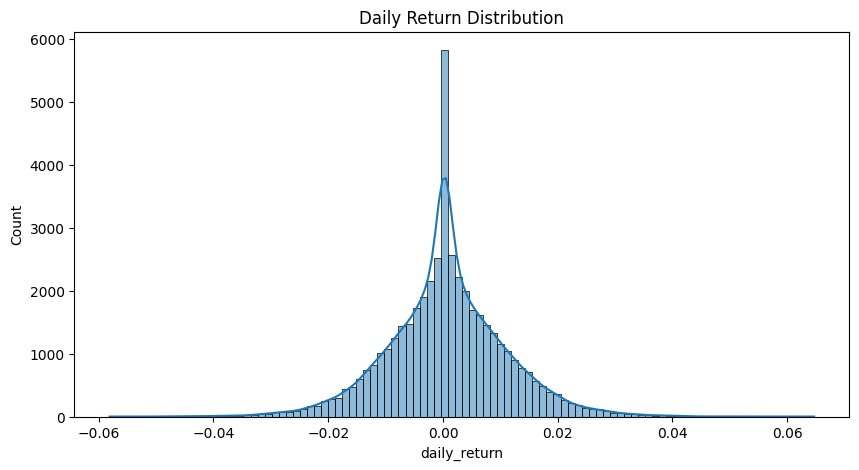

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Daily Return Distribution")
plt.show()

In [111]:
def calculate_cagr(df):

    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]

    years = (
        (df.iloc[-1]["date"] - df.iloc[0]["date"]).days
        / 365
    )

    cagr = (
        (end_nav/start_nav)**(1/years)
        - 1
    )

    return cagr

In [112]:
cagr_table = (
    nav.groupby("amfi_code")
    .apply(calculate_cagr)
    .reset_index()
)

cagr_table.columns = [
    "amfi_code",
    "cagr"
]

cagr_table.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [113]:
RF = 0.065
def sharpe_ratio(df):

    r = df["daily_return"].dropna()

    annual_return = r.mean()*252

    annual_std = r.std()*np.sqrt(252)

    sharpe = (
        (annual_return-RF)
        / annual_std
    )

    return sharpe
sharpe_table = (
    nav.groupby("amfi_code")
    .apply(sharpe_ratio)
    .reset_index()
)

sharpe_table.columns = [
    "amfi_code",
    "sharpe_ratio"
]

sharpe_table.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [114]:
def sortino_ratio(df):

    r = df["daily_return"].dropna()

    downside = r[r < 0]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        r.mean()*252
    )

    return (
        annual_return-RF
    ) / downside_std
print(benchmark.columns.tolist())
print(benchmark.head())

['date', 'index_name', 'close_value']
        date index_name  close_value
0 2022-01-03    NIFTY50     17492.79
1 2022-01-04    NIFTY50     17689.64
2 2022-01-05    NIFTY50     17835.05
3 2022-01-06    NIFTY50     17878.51
4 2022-01-07    NIFTY50     17759.15


In [115]:
benchmark = benchmark.sort_values(
    ["index_name","date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")
    ["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [116]:
nifty100 = benchmark[
    benchmark["index_name"]=="NIFTY100"
].copy()

nifty100.head()
print(nifty100.shape)

(1150, 4)


In [117]:
from scipy.stats import linregress
def alpha_beta(fund_df):

    merged = pd.merge(
        fund_df[["date","daily_return"]],
        nifty100[["date","benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        return pd.Series([np.nan,np.nan])

    slope, intercept, r, p, stderr = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252
    beta = slope

    return pd.Series([alpha,beta])
alpha_beta_table = (
    nav.groupby("amfi_code")
    .apply(alpha_beta)
    .reset_index()
)

alpha_beta_table.columns = [
    "amfi_code",
    "alpha",
    "beta"
]

alpha_beta_table.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [118]:
alpha_beta_table.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [119]:
def max_drawdown(df):

    running_max = df["nav"].cummax()

    drawdown = (
        df["nav"]/running_max
        - 1
    )

    return drawdown.min()
drawdown_table = (
    nav.groupby("amfi_code")
    .apply(max_drawdown)
    .reset_index()
)

drawdown_table.columns = [
    "amfi_code",
    "max_drawdown"
]

drawdown_table.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [120]:
scorecard = (
    cagr_table
    .merge(sharpe_table,on="amfi_code")
    .merge(alpha_beta_table,on="amfi_code")
    .merge(drawdown_table,on="amfi_code")
)
scorecard["return_rank"] = (
    scorecard["cagr"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["dd_rank"] = (
    (-scorecard["max_drawdown"])
    .rank(pct=True)
)
scorecard["fund_score"] = (

      scorecard["return_rank"]*30

    + scorecard["sharpe_rank"]*25

    + scorecard["alpha_rank"]*20

    + scorecard["dd_rank"]*10

)
scorecard.sort_values(
    "fund_score",
    ascending=False
).head(10)

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,dd_rank,fund_score
25,120505,0.328016,1.180101,0.292636,0.000549,-0.181885,1.000,0.900,0.950,0.625,77.750
36,148569,0.319245,1.234930,0.282704,0.018134,-0.163967,0.925,0.950,0.925,0.525,75.250
21,119598,0.323981,0.945308,0.303370,-0.023196,-0.287060,0.975,0.675,1.000,0.900,75.125
39,149324,0.322621,0.949796,0.300579,0.011455,-0.311719,0.950,0.700,0.975,0.925,74.750
30,120843,0.308833,1.306744,0.273305,-0.022830,-0.129740,0.875,0.975,0.900,0.325,71.875
34,148567,0.309499,1.448291,0.269838,0.023684,-0.112657,0.900,1.000,0.850,0.200,71.000
2,100033,0.300997,1.093699,0.271954,0.005104,-0.162172,0.850,0.850,0.875,0.500,69.250
38,149323,0.295581,1.132122,0.265986,-0.002523,-0.172481,0.825,0.875,0.825,0.550,68.625
19,119551,0.257849,1.208267,0.232010,-0.031751,-0.150124,0.775,0.925,0.775,0.425,66.125
16,119094,0.281926,0.998231,0.260767,-0.066265,-0.209609,0.800,0.750,0.800,0.700,65.750


In [121]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [122]:
top5 = (
    scorecard
    .sort_values(
        "fund_score",
        ascending=False
    )
    .head(5)
)

top5_codes = top5["amfi_code"].tolist()

top5_codes
import plotly.express as px

plot_data = nav[
    nav["amfi_code"]
    .isin(top5_codes)
]

fig = px.line(
    plot_data,
    x="date",
    y="nav",
    color="amfi_code",
    title="Top 5 Funds NAV Comparison"
)

fig.show()